# FIG CESM run evaluations

In [1]:
import os
import sys
import yaml
import argparse
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [2]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [3]:
import matplotlib.lines as mlines

In [4]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [5]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

### Data

In [8]:
fn_save = '/glade/campaign/ral/hap/ksha/GWC_results/scores/ZES/teacher.npy'
dict_all = np.load(fn_save, allow_pickle=True)[()]

### Plot

In [11]:
my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = my_colors['cyan']
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

cmap = plt.get_cmap('Spectral')
n = 5
colors = cmap(np.linspace(0, 0.3, 8))  # returns RGBA, shape (n, 4)

line_keys = {}
line_keys['target_WRF'] = {'linewidth': 4, 'linestyle': '-', 'color': '0.75', 'alpha': 1, 'zorder': 1, 'label': ''}
line_keys['TF01'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[0], 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['TF06'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[1], 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['TF12'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[2], 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['TF24'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[3], 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['TF36'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[4], 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['TF48'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[5], 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['TF60'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[6], 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['B6H_WRF'] = {'linewidth': 2.5, 'linestyle': '--', 'color': colors[7], 'alpha': 1, 'zorder': 4, 'label': ''}

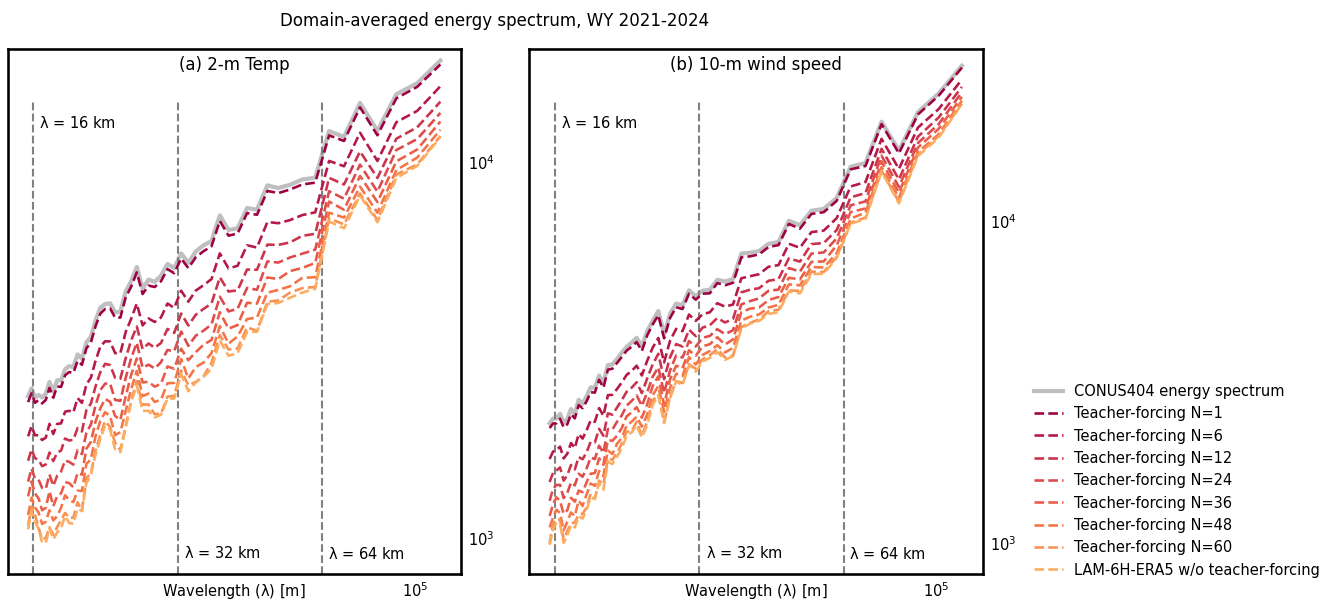

In [12]:
title_zes = [
    '(a) 2-m Temp', 
    '(b) 10-m wind speed',
]

fig = plt.figure(figsize=(13, 7), dpi=dpi_)
gs = gridspec.GridSpec(1, 2, height_ratios=[1,], width_ratios=[1, 1])

AX_zes = []
AX_zes.append(plt.subplot(gs[0, 0]))
AX_zes.append(plt.subplot(gs[0, 1]))

for ax in AX_zes:
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelright=True, labelsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(labelbottom=True, labelsize=14)
    ax.set_xlabel('Wavelength ($\mathsf{\lambda}$) [m]', fontsize=14, labelpad=-18)
    
plt.subplots_adjust(0, 0, 1, 1, hspace=0., wspace=0.15)

YLIMs  = [[8e2, 2e4], [8e2, 3.4e4]]
YTICKS = [[1e3, 1e4], [1e3, 1e4]]
X_VLIME = [16000, 32000, 64000]

for i_var, varname in enumerate(['SPD10_zes', 'T2_zes']):
    for exp_name in ['target_WRF', 'TF01', 'TF06', 'TF12', 'TF24', 'TF36', 'TF48', 'TF60', 'B6H_WRF']:
        # cut too small and too big wavelength
        AX_zes[i_var].plot(
            dict_all['target_lambda'][106:-8], 
            dict_all[f'{exp_name}_{varname}'][106:-8], **line_keys[exp_name]) #  

    AX_zes[i_var].set_ylim(YLIMs[i_var])
    AX_zes[i_var].set_yticks(YTICKS[i_var])
    AX_zes[i_var].set_title(title_zes[i_var], fontsize=16, y=0.95)
    
    for x_vline in X_VLIME:
        AX_zes[i_var].axvline(x=x_vline, color='0.5', linestyle='--', linewidth=2, ymin=0.0, ymax=0.9)

    AX_zes[i_var].text(
        0.07, 0.875, '$\mathsf{\lambda}$ = 16 km', 
        ha='left', va='top', fontsize=14, transform=AX_zes[i_var].transAxes)

    AX_zes[i_var].text(
        0.375+0.015, 0.025, '$\mathsf{\lambda}$ = 32 km', 
        ha='left', va='bottom', fontsize=14, transform=AX_zes[i_var].transAxes)

    AX_zes[i_var].text(
        0.681+0.025, 0.024, '$\mathsf{\lambda}$ = 64 km', 
        ha='left', va='bottom', fontsize=14, transform=AX_zes[i_var].transAxes)


handle_legneds1 = []
handle_legneds1.append(mlines.Line2D([], [], **line_keys['target_WRF']))

for step in ['01', '06', '12', '24', '36', '48', '60']:
    handle_legneds1.append(mlines.Line2D([], [], **line_keys[f'TF{step}']))

handle_legneds1.append(mlines.Line2D([], [], **line_keys['B6H_WRF']))

ax_lg1 = fig.add_axes([1.03, -0.0225, 0.33, 0.41])
LG1 = ax_lg1.legend(
    handle_legneds1, 
    ['CONUS404 energy spectrum', 
     'Teacher-forcing N=1', 
     'Teacher-forcing N=6', 
     'Teacher-forcing N=12', 
     'Teacher-forcing N=24', 
     'Teacher-forcing N=36', 
     'Teacher-forcing N=48', 
     'Teacher-forcing N=60', 
     'LAM-6H-ERA5 w/o teacher-forcing',],
    bbox_to_anchor=(1, 1), ncol=1, prop={'size':14}
)

ax_title2 = fig.add_axes([0.5*(1-0.45), 1.03, 0.45, 0.05])
ax_title2.text(
    0.5, 0.5, 
    'Domain-averaged energy spectrum, WY 2021-2024',
    fontsize=16, va='center', ha='center', transform=ax_title2.transAxes
)

LG1 = gu.lg_box(LG1)
ax_title2.set_axis_off()
ax_lg1.set_axis_off()